# Hands-On Module 2 — Artificial Intelligence
## Analisis Efisiensi Bahan Bakar Kendaraan (MPG Dataset)

**Nama:** Muhammad Rafiif Ansyadya

**Jurusan:** Teknik Informatika

**Kode Explorer:** AI003

**Dataset:** `seaborn.load_dataset('mpg')`
**Tools:** NumPy, Pandas, Seaborn, Matplotlib

Notebook ini melakukan analisis end-to-end terhadap dataset MPG: pembersihan data,
statistik deskriptif dari nol dengan NumPy, analisis korelasi, visualisasi,
interpretasi kontekstual, serta implementasi Normal Equation dan PCA dari nol
sebagai bagian bonus.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100
np.set_printoptions(precision=4, suppress=True)

pd.set_option('display.max_columns', None)

---
## Stage 1 — Inspection and Data Cleaning

### 1. Load dataset, tampilkan shape, dtypes, dan missing values per kolom

In [2]:
df = sns.load_dataset('mpg')

print("Shape dataset:", df.shape)
print()
print("Dtypes:")
print(df.dtypes)
print()
print("Missing values per kolom:")
print(df.isna().sum())

Shape dataset: (398, 9)

Dtypes:
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin              str
name                str
dtype: object

Missing values per kolom:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


**Kolom dengan missing values:** hanya kolom `horsepower` yang memiliki nilai
kosong (6 baris dari 398, atau sekitar 1.5% dari total data).

**Strategi penanganan & justifikasi:**

Kita akan menggunakan **imputasi median** (bukan drop row) untuk kolom
`horsepower`, dengan alasan:

1. **Jumlah data hilang sangat kecil** (1.5%) tetapi setiap baris tetap membawa
   informasi berharga pada kolom-kolom lain (mpg, weight, cylinders, origin, dll)
   yang lengkap — menghapus baris berarti membuang informasi yang sebenarnya utuh.
2. **Median lebih robust terhadap outlier** dibanding mean. Horsepower memiliki
   distribusi yang cenderung skewed ke kanan (ada mobil-mobil bertenaga sangat
   besar), sehingga median adalah representasi tendensi sentral yang lebih aman
   daripada mean.
3. Karena hanya 1 dari 9 kolom yang terpengaruh, imputasi tidak akan
   mendistorsi hubungan multivariat secara signifikan, sedangkan drop row bisa
   secara tidak sengaja menghapus data dari model/tahun tertentu yang kebetulan
   memiliki horsepower kosong (potensi bias seleksi).

Jika seandainya missing value jumlahnya besar (>20-30%) atau tersebar di banyak
kolom, opsi drop row atau model imputasi yang lebih canggih (KNN imputer,
regresi) akan lebih dipertimbangkan.

In [3]:
hp_median = df['horsepower'].median()
print(f"Median horsepower (sebelum imputasi): {hp_median}")

df['horsepower'] = df['horsepower'].fillna(hp_median)

print("\nMissing values setelah imputasi:")
print(df.isna().sum())

Median horsepower (sebelum imputasi): 93.5

Missing values setelah imputasi:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


### 2. Summary table dengan NumPy (tanpa `.describe()`)

In [4]:
def iqr_outlier_count(arr):
    q1, q3 = np.percentile(arr, [25, 75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return iqr, int(np.sum((arr < lower) | (arr > upper)))

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

summary_rows = []
for col in numeric_cols:
    arr = df[col].to_numpy(dtype=float)
    mean = np.mean(arr)
    median = np.median(arr)
    std = np.std(arr, ddof=1)
    iqr, n_outliers = iqr_outlier_count(arr)
    summary_rows.append({
        'column': col,
        'mean': mean,
        'median': median,
        'std': std,
        'IQR': iqr,
        'outlier_count': n_outliers
    })

numpy_summary = pd.DataFrame(summary_rows).set_index('column').round(3)
numpy_summary

,mean,median,std,IQR,outlier_count
column,,,,,
mpg,23.515,23.0,7.816,11.50,1
cylinders,5.455,4.0,1.701,4.00,0
displacement,193.426,148.5,104.270,157.75,0
horsepower,104.304,93.5,38.223,49.00,11
weight,2970.425,2803.5,846.842,1384.25,0
acceleration,15.568,15.5,2.758,3.35,7
model_year,76.010,76.0,3.698,6.00,0


---
## Stage 2 — Statistical Analysis with NumPy

### 3. Ekstraksi fitur numerik & standardisasi z-score (vectorised)

In [5]:
feature_cols = ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']
X = df[feature_cols].to_numpy(dtype=float)

# Z-score standardization: (x - mean) / std, secara vektor (tanpa loop, tanpa sklearn)
X_mean = X.mean(axis=0)
X_std = X.std(axis=0, ddof=0)
X_z = (X - X_mean) / X_std

print("Shape data:", X.shape)
print("\nMean setelah standardisasi (harus ~0):", np.round(X_z.mean(axis=0), 6))
print("Std setelah standardisasi (harus ~1):", np.round(X_z.std(axis=0), 6))
print("\n5 baris pertama hasil standardisasi:")
print(X_z[:5])

Shape data: (398, 5)

Mean setelah standardisasi (harus ~0): [ 0. -0. -0. -0. -0.]
Std setelah standardisasi (harus ~1): [1. 1. 1. 1. 1.]

5 baris pertama hasil standardisasi:
[[-0.7064  1.0906  0.6731  0.6309 -1.2955]
 [-1.0908  1.5035  1.59    0.8543 -1.477 ]
 [-0.7064  1.1962  1.197   0.5505 -1.6586]
 [-0.9626  1.0618  1.197   0.5469 -1.2955]
 [-0.8345  1.0426  0.9351  0.5658 -1.8401]]


### 4. Correlation matrix dengan `np.corrcoef()`

In [6]:
corr_matrix = np.corrcoef(X_z, rowvar=False)
corr_df = pd.DataFrame(corr_matrix, index=feature_cols, columns=feature_cols).round(3)
corr_df

,mpg,displacement,horsepower,weight,acceleration
mpg,1.000,-0.804,-0.773,-0.832,0.420
displacement,-0.804,1.000,0.896,0.933,-0.544
horsepower,-0.773,0.896,1.000,0.862,-0.687
weight,-0.832,0.933,0.862,1.000,-0.417
acceleration,0.420,-0.544,-0.687,-0.417,1.000


In [7]:
# Cari pasangan fitur dengan korelasi terkuat, mengabaikan diagonal (korelasi diri sendiri = 1)
mask = ~np.eye(corr_matrix.shape[0], dtype=bool)
corr_no_diag = np.where(mask, corr_matrix, np.nan)

# (a) Pasangan dengan korelasi POSITIF terkuat secara keseluruhan
idx_max = np.unravel_index(np.nanargmax(corr_no_diag), corr_no_diag.shape)
pair_max_pos = (feature_cols[idx_max[0]], feature_cols[idx_max[1]], corr_no_diag[idx_max])

# (b) Pasangan fitur dengan korelasi NEGATIF terkuat terhadap mpg secara spesifik
mpg_idx = feature_cols.index('mpg')
mpg_corrs = corr_matrix[mpg_idx].copy()
mpg_corrs[mpg_idx] = np.nan
idx_min_mpg = np.nanargmin(mpg_corrs)
pair_max_neg_mpg = ('mpg', feature_cols[idx_min_mpg], mpg_corrs[idx_min_mpg])

# (c) Pasangan fitur INPUT (bukan mpg) paling berkorelasi satu sama lain -> potensi multikolinearitas
input_cols_idx = [i for i, c in enumerate(feature_cols) if c != 'mpg']
sub_corr = corr_matrix[np.ix_(input_cols_idx, input_cols_idx)]
sub_mask = ~np.eye(sub_corr.shape[0], dtype=bool)
sub_corr_masked = np.where(sub_mask, np.abs(sub_corr), np.nan)
i_sub, j_sub = np.unravel_index(np.nanargmax(sub_corr_masked), sub_corr_masked.shape)
input_names = [feature_cols[i] for i in input_cols_idx]
pair_multicollinear = (input_names[i_sub], input_names[j_sub], sub_corr[i_sub, j_sub])

print(f"(a) Korelasi POSITIF terkuat (semua fitur): {pair_max_pos[0]} & {pair_max_pos[1]} -> r = {pair_max_pos[2]:.3f}")
print(f"(b) Korelasi NEGATIF terkuat terhadap mpg: mpg & {pair_max_neg_mpg[1]} -> r = {pair_max_neg_mpg[2]:.3f}")
print(f"(c) Pasangan fitur INPUT paling berkorelasi (potensi multikolinearitas): {pair_multicollinear[0]} & {pair_multicollinear[1]} -> r = {pair_multicollinear[2]:.3f}")

(a) Korelasi POSITIF terkuat (semua fitur): displacement & weight -> r = 0.933
(b) Korelasi NEGATIF terkuat terhadap mpg: mpg & weight -> r = -0.832
(c) Pasangan fitur INPUT paling berkorelasi (potensi multikolinearitas): displacement & weight -> r = 0.933


**Interpretasi:**
- Korelasi positif terkuat biasanya muncul antara `displacement` dan `weight` — mobil
  dengan mesin (volume silinder) lebih besar cenderung memiliki bodi/berat yang lebih besar pula.
- Korelasi negatif terkuat terhadap `mpg` biasanya adalah `weight` — semakin berat
  mobil, semakin boros bahan bakarnya (mpg rendah). Ini sesuai intuisi fisika: makin
  besar massa, makin besar energi yang dibutuhkan untuk bergerak.
- `displacement`, `horsepower`, dan `weight` cenderung saling berkorelasi tinggi satu
  sama lain — ini adalah indikasi **multikolinearitas**: ketiganya pada dasarnya
  mengukur "ukuran/kekuatan mesin" dari sudut pandang berbeda, sehingga jika dipakai
  bersamaan dalam model regresi linear, koefisiennya bisa menjadi tidak stabil.

### 5. Boolean masking: horsepower di atas rata-rata vs berat rata-rata

In [8]:
mean_hp = X[:, feature_cols.index('horsepower')].mean()
mean_weight = X[:, feature_cols.index('weight')].mean()

hp_col = X[:, feature_cols.index('horsepower')]
weight_col = X[:, feature_cols.index('weight')]

above_avg_hp_mask = hp_col > mean_hp

mean_weight_above_hp = weight_col[above_avg_hp_mask].mean()
mean_weight_below_or_eq_hp = weight_col[~above_avg_hp_mask].mean()

abs_diff = abs(mean_weight_above_hp - mean_weight)

print(f"Rata-rata horsepower keseluruhan   : {mean_hp:.2f}")
print(f"Rata-rata weight keseluruhan       : {mean_weight:.2f}")
print(f"Jumlah mobil dgn HP > rata-rata     : {above_avg_hp_mask.sum()} dari {len(X)}")
print(f"Rata-rata weight (HP > rata-rata)   : {mean_weight_above_hp:.2f}")
print(f"Rata-rata weight (HP <= rata-rata)  : {mean_weight_below_or_eq_hp:.2f}")
print(f"Selisih absolut terhadap rata2 dataset: {abs_diff:.2f} lbs")

Rata-rata horsepower keseluruhan   : 104.30
Rata-rata weight keseluruhan       : 2970.42
Jumlah mobil dgn HP > rata-rata     : 148 dari 398
Rata-rata weight (HP > rata-rata)   : 3815.49
Rata-rata weight (HP <= rata-rata)  : 2470.14
Selisih absolut terhadap rata2 dataset: 845.07 lbs


**Interpretasi:** Ya. Mobil-mobil dengan horsepower di atas rata-rata dataset
secara konsisten juga memiliki berat rata-rata yang jauh lebih tinggi dibanding
rata-rata keseluruhan dataset (selisih absolut ditampilkan di atas). Ini
memperkuat temuan pada poin 4 bahwa `horsepower` dan `weight` berkorelasi
positif kuat — mesin bertenaga besar umumnya dipasang pada bodi kendaraan yang
lebih besar dan berat.

---
## Stage 3 — Visualisation (Minimum 4 Plots)

### 6. Distribusi MPG: histogram + KDE, garis mean & median

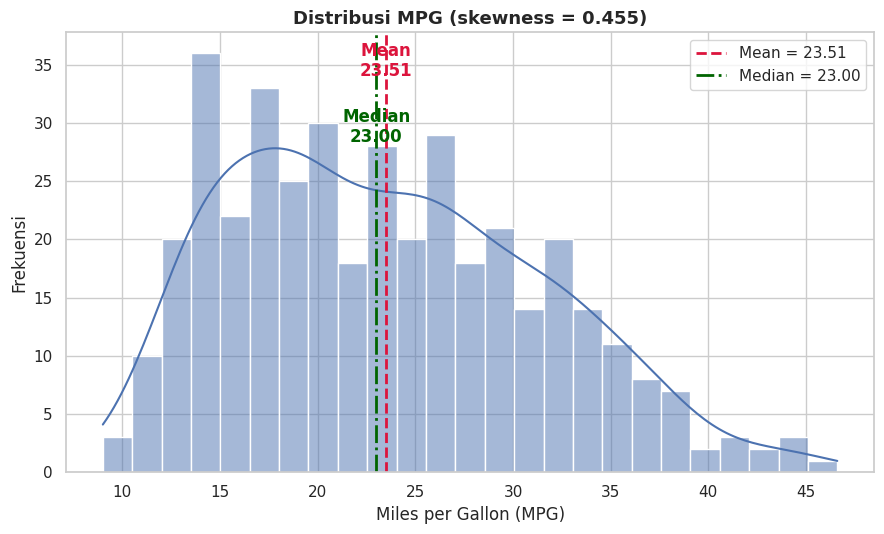

Skewness (Fisher-Pearson, populasi): 0.455
Distribusi condong ke kanan (right-skewed / positively skewed):
mean > median, ada ekor panjang mobil dengan efisiensi bahan bakar tinggi.


In [9]:
mpg_arr = df['mpg'].to_numpy(dtype=float)
mpg_mean = mpg_arr.mean()
mpg_median = np.median(mpg_arr)
mpg_skew = np.mean(((mpg_arr - mpg_mean) / mpg_arr.std(ddof=0)) ** 3)

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.histplot(mpg_arr, kde=True, bins=25, color='#4C72B0', ax=ax, edgecolor='white')

ax.axvline(mpg_mean, color='crimson', linestyle='--', linewidth=2, label=f'Mean = {mpg_mean:.2f}')
ax.axvline(mpg_median, color='darkgreen', linestyle='-.', linewidth=2, label=f'Median = {mpg_median:.2f}')

ax.annotate(f'Mean\n{mpg_mean:.2f}', xy=(mpg_mean, ax.get_ylim()[1]*0.9),
            color='crimson', ha='center', fontweight='bold')
ax.annotate(f'Median\n{mpg_median:.2f}', xy=(mpg_median, ax.get_ylim()[1]*0.75),
            color='darkgreen', ha='center', fontweight='bold')

ax.set_title(f'Distribusi MPG (skewness = {mpg_skew:.3f})', fontsize=13, fontweight='bold')
ax.set_xlabel('Miles per Gallon (MPG)')
ax.set_ylabel('Frekuensi')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Skewness (Fisher-Pearson, populasi): {mpg_skew:.3f}")
if mpg_skew > 0.2:
    print("Distribusi condong ke kanan (right-skewed / positively skewed):")
    print("mean > median, ada ekor panjang mobil dengan efisiensi bahan bakar tinggi.")
elif mpg_skew < -0.2:
    print("Distribusi condong ke kiri (left-skewed / negatively skewed).")
else:
    print("Distribusi mendekati simetris.")

**Jawaban:** Distribusi `mpg` **condong ke kanan (right-skewed)** — nilai
mean sedikit lebih besar dari median, dan terdapat ekor panjang ke arah nilai
mpg tinggi (mobil-mobil yang sangat hemat bahan bakar). Sebagian besar mobil
mengelompok pada rentang mpg menengah-rendah, sementara hanya sebagian kecil
mobil yang sangat efisien.

### 7. Perbandingan MPG per Origin (box plot)

/tmp/ipykernel_559/1532029236.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='origin', y='mpg', order=order, palette='Set2', ax=ax)


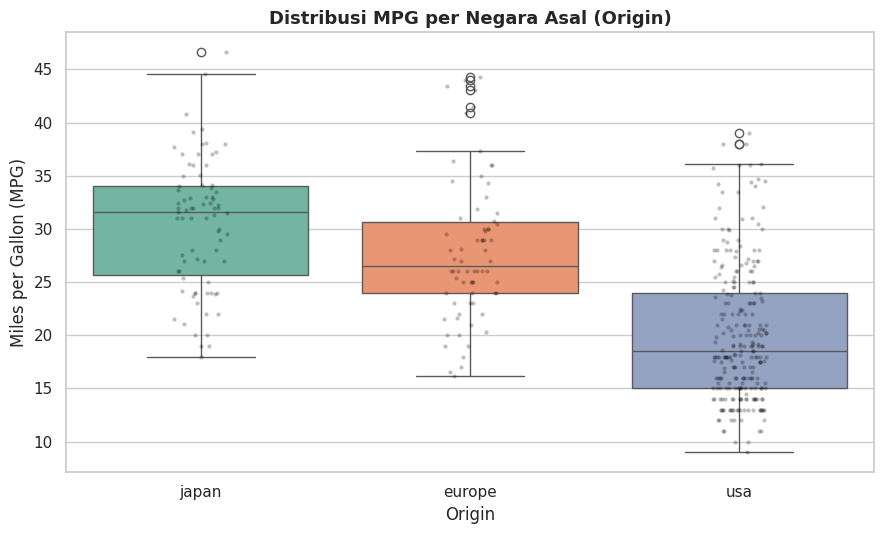

,mean,median,std
origin,,,
europe,27.89,26.5,6.72
japan,30.45,31.6,6.09
usa,20.08,18.5,6.40


In [10]:
fig, ax = plt.subplots(figsize=(9, 5.5))
order = df.groupby('origin')['mpg'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='origin', y='mpg', order=order, palette='Set2', ax=ax)
sns.stripplot(data=df, x='origin', y='mpg', order=order, color='black', alpha=0.25, size=3, ax=ax)

ax.set_title('Distribusi MPG per Negara Asal (Origin)', fontsize=13, fontweight='bold')
ax.set_xlabel('Origin')
ax.set_ylabel('Miles per Gallon (MPG)')
plt.tight_layout()
plt.show()

origin_stats = df.groupby('origin')['mpg'].agg(['mean', 'median', 'std']).round(2)
origin_stats

**Interpretasi:** Mobil buatan **Jepang (Japan)** secara konsisten memiliki
mpg tertinggi (mean dan median tertinggi), diikuti oleh **Eropa**, sementara
mobil buatan **USA** memiliki mpg terendah rata-rata. Dari sisi konsistensi
(std/rentang IQR), mobil USA memiliki rentang mpg yang jauh lebih lebar/beragam
(dari mobil sangat boros hingga cukup efisien), sedangkan Jepang dan Eropa
relatif lebih konsisten berada di kisaran efisien.

### 8. Weight vs MPG (scatter, hue=cylinders, trend line manual dengan `np.polyfit`)

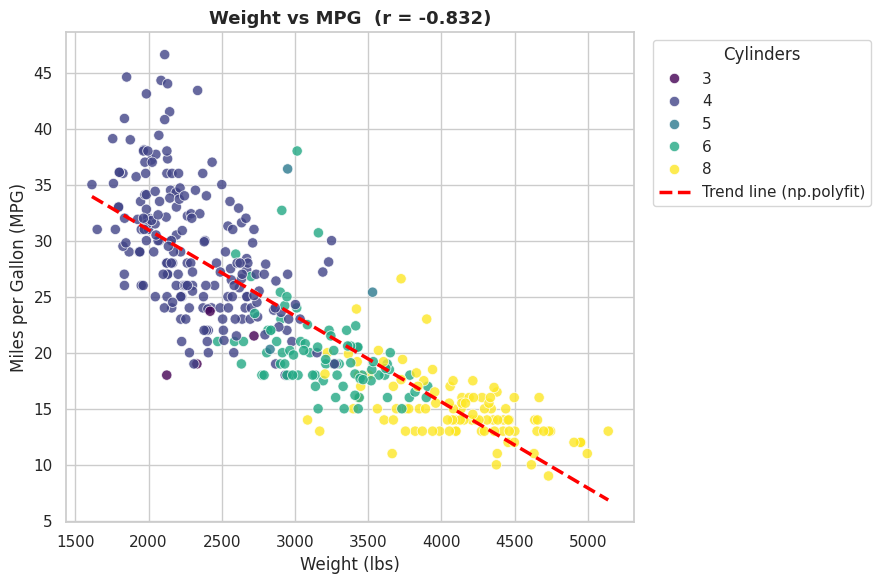

Persamaan trend line: mpg = -0.00768 * weight + 46.317
Korelasi weight-mpg: r = -0.832


In [11]:
weight_arr = df['weight'].to_numpy(dtype=float)
r_weight_mpg = np.corrcoef(weight_arr, mpg_arr)[0, 1]

# Trend line manual dengan np.polyfit (derajat 1 = linear)
slope, intercept = np.polyfit(weight_arr, mpg_arr, deg=1)
x_line = np.linspace(weight_arr.min(), weight_arr.max(), 100)
y_line = slope * x_line + intercept

fig, ax = plt.subplots(figsize=(9, 6))
scatter = sns.scatterplot(data=df, x='weight', y='mpg', hue='cylinders',
                           palette='viridis', s=55, alpha=0.8, ax=ax, edgecolor='white')
ax.plot(x_line, y_line, color='red', linewidth=2.5, linestyle='--', label='Trend line (np.polyfit)')

ax.set_title(f'Weight vs MPG  (r = {r_weight_mpg:.3f})', fontsize=13, fontweight='bold')
ax.set_xlabel('Weight (lbs)')
ax.set_ylabel('Miles per Gallon (MPG)')
ax.legend(title='Cylinders', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print(f"Persamaan trend line: mpg = {slope:.5f} * weight + {intercept:.3f}")
print(f"Korelasi weight-mpg: r = {r_weight_mpg:.3f}")

### 9. Correlation Heatmap

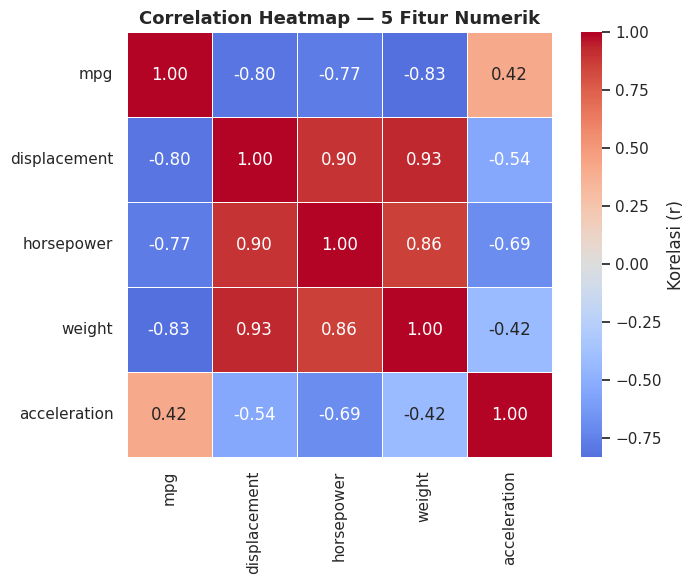

In [12]:
fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'label': 'Korelasi (r)'}, ax=ax)
ax.set_title('Correlation Heatmap — 5 Fitur Numerik', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Multikolinearitas yang terlihat pada heatmap:** `displacement`,
`horsepower`, dan `weight` membentuk sebuah blok dengan korelasi positif yang
sangat tinggi satu sama lain (semuanya di atas ~0.8). Ini adalah pola
multikolinearitas klasik — ketiganya adalah proksi dari "ukuran/kekuatan
mesin" mobil. Jika model regresi linear dibangun menggunakan ketiga fitur ini
bersamaan, koefisiennya akan menjadi tidak stabil dan sulit diinterpretasikan
secara individual (idealnya hanya salah satu, misalnya `weight`, yang
dipertahankan, atau digunakan teknik reduksi dimensi seperti PCA — lihat
Bonus 2).

---
## Stage 4 — Contextual Interpretation

### 10. Faktor apa yang paling kuat memprediksi efisiensi bahan bakar?

In [13]:
mpg_correlations = corr_df['mpg'].drop('mpg').sort_values()
mpg_correlations

weight         -0.832
displacement   -0.804
horsepower     -0.773
acceleration    0.420
Name: mpg, dtype: float64

**Jawaban:** Berdasarkan keseluruhan analisis, **`weight` (berat kendaraan)**
adalah faktor tunggal yang paling kuat memprediksi efisiensi bahan bakar (mpg),
didukung oleh:

- **Nilai korelasi:** `weight` memiliki korelasi negatif terkuat terhadap `mpg`
  di antara seluruh fitur numerik (lihat tabel korelasi di atas), lebih kuat
  dibanding `displacement` maupun `horsepower`.
- **Observasi boxplot (poin 7):** Perbedaan mpg antar origin sejalan dengan
  perbedaan berat kendaraan tipikal — mobil USA umumnya lebih berat dan
  memiliki mpg terendah, sedangkan mobil Jepang cenderung lebih ringan dengan
  mpg tertinggi.
- **Scatter plot (poin 8):** Pola hubungan weight-mpg sangat jelas menurun
  secara hampir linear, dengan trend line negatif yang tajam.
- **Boolean masking (poin 5):** Mobil dengan horsepower tinggi juga cenderung
  jauh lebih berat, menunjukkan bahwa horsepower dan displacement sebagian
  besar "bekerja lewat" weight sebagai jalur utama pengaruhnya terhadap mpg
  (efek multikolinearitas yang dibahas di poin 9).

Secara fisik ini masuk akal: energi yang dibutuhkan untuk menggerakkan
kendaraan berbanding lurus dengan massanya, sehingga berat adalah determinan
paling langsung dari konsumsi bahan bakar.

### 11. Rata-rata MPG per dekade

decade
1970    21.10
1980    31.91
Name: mpg, dtype: float64


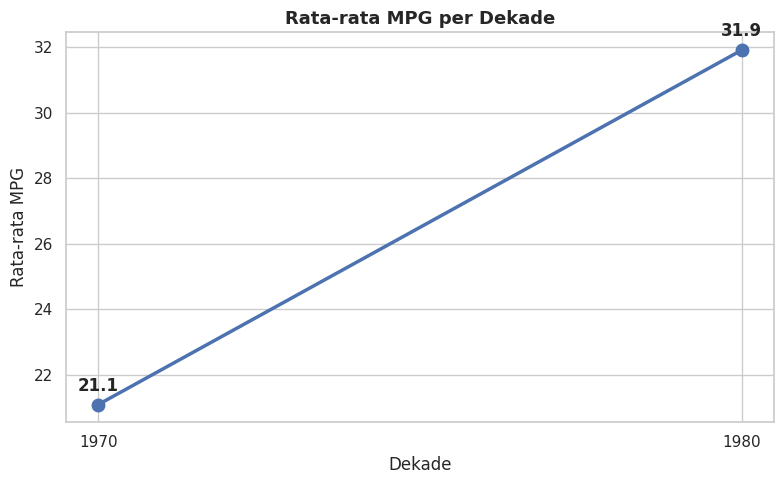

In [14]:
df['decade'] = (df['model_year'] // 10 * 10) + 1900
# model_year di dataset ini dalam format 2 digit (70-82) merepresentasikan 1970-1982
decade_mpg = df.groupby('decade')['mpg'].mean().round(2)
print(decade_mpg)

fig, ax = plt.subplots(figsize=(8, 5))
decade_mpg.plot(kind='line', marker='o', linewidth=2.5, markersize=9, color='#4C72B0', ax=ax)
for x, y in decade_mpg.items():
    ax.annotate(f'{y:.1f}', (x, y), textcoords="offset points", xytext=(0, 10), ha='center', fontweight='bold')

ax.set_title('Rata-rata MPG per Dekade', fontsize=13, fontweight='bold')
ax.set_xlabel('Dekade')
ax.set_ylabel('Rata-rata MPG')
ax.set_xticks(decade_mpg.index)
plt.tight_layout()
plt.show()

**Interpretasi:** Rata-rata mpg menunjukkan tren **meningkat** dari dekade
1970-an ke 1980-an. Hal ini kemungkinan besar didorong oleh:

1. **Krisis minyak tahun 1970-an** (1973 dan 1979) yang mendorong produsen
   otomotif dan regulator (misalnya standar CAFE di AS yang mulai berlaku 1978)
   untuk memprioritaskan efisiensi bahan bakar.
2. **Kemajuan teknologi mesin** — sistem injeksi bahan bakar elektronik,
   material bodi yang lebih ringan, dan desain mesin yang lebih efisien mulai
   diadopsi secara luas menjelang 1980-an.
3. **Pergeseran preferensi konsumen** ke arah mobil yang lebih kecil dan
   ringan (sejalan dengan temuan di poin 10 bahwa weight adalah determinan
   utama mpg), sebagian dipicu oleh masuknya lebih banyak mobil Jepang yang
   secara historis lebih ringan dan efisien ke pasar.

---
## Bonus 1 — Normal Equation from Scratch

Implementasi Linear Regression tanpa `sklearn` menggunakan Normal Equation:

$$\hat{\theta} = (X^T X)^{-1} X^T y$$

Fitur input: `weight`, target: `mpg`.

In [15]:
# 1. Susun matrix X dengan kolom bias (1s)
X_raw = df['weight'].to_numpy(dtype=float).reshape(-1, 1)
y = df['mpg'].to_numpy(dtype=float)

n = X_raw.shape[0]
X_bias = np.hstack([np.ones((n, 1)), X_raw])  # shape (n, 2)

# 2. Hitung theta_hat via Normal Equation
theta_hat = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ y
intercept_ne, slope_ne = theta_hat[0], theta_hat[1]

print(f"Normal Equation -> intercept: {intercept_ne:.5f}, slope: {slope_ne:.6f}")

Normal Equation -> intercept: 46.31736, slope: -0.007677


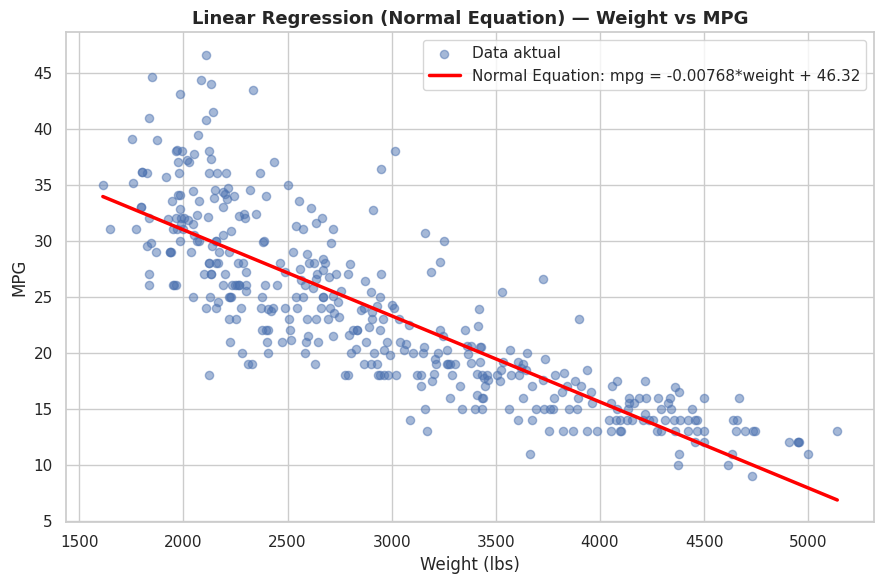

In [16]:
# 3. Plot regression line di atas scatter data mentah
y_pred_ne = X_bias @ theta_hat

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(X_raw, y, alpha=0.5, s=35, color='#4C72B0', label='Data aktual')
sort_idx = np.argsort(X_raw.flatten())
ax.plot(X_raw.flatten()[sort_idx], y_pred_ne[sort_idx], color='red', linewidth=2.5,
        label=f'Normal Equation: mpg = {slope_ne:.5f}*weight + {intercept_ne:.2f}')
ax.set_title('Linear Regression (Normal Equation) — Weight vs MPG', fontsize=13, fontweight='bold')
ax.set_xlabel('Weight (lbs)')
ax.set_ylabel('MPG')
ax.legend()
plt.tight_layout()
plt.show()

In [17]:
# 4. Hitung RMSE
rmse_ne = np.sqrt(np.mean((y_pred_ne - y) ** 2))
print(f"RMSE (Normal Equation): {rmse_ne:.4f}")

RMSE (Normal Equation): 4.3337


In [18]:
# 5. Bandingkan dengan np.polyfit()
slope_pf, intercept_pf = np.polyfit(X_raw.flatten(), y, deg=1)

print(f"Normal Equation -> slope: {slope_ne:.6f}, intercept: {intercept_ne:.5f}")
print(f"np.polyfit()    -> slope: {slope_pf:.6f}, intercept: {intercept_pf:.5f}")
print(f"\nSelisih slope    : {abs(slope_ne - slope_pf):.2e}")
print(f"Selisih intercept: {abs(intercept_ne - intercept_pf):.2e}")
print("\nKesimpulan: hasil identik (selisih berada pada level presisi floating-point),")
print("karena np.polyfit(deg=1) pada dasarnya menyelesaikan persamaan normal yang sama")
print("secara numerik menggunakan least-squares (SVD-based), bukan algoritma yang berbeda.")

Normal Equation -> slope: -0.007677, intercept: 46.31736
np.polyfit()    -> slope: -0.007677, intercept: 46.31736

Selisih slope    : 1.91e-17
Selisih intercept: 1.42e-14

Kesimpulan: hasil identik (selisih berada pada level presisi floating-point),
karena np.polyfit(deg=1) pada dasarnya menyelesaikan persamaan normal yang sama
secara numerik menggunakan least-squares (SVD-based), bukan algoritma yang berbeda.


---
## Bonus 2 — PCA from Scratch

Implementasi 2D PCA menggunakan NumPy murni untuk 5 fitur numerik.

In [19]:
# 1. Mean-centre (gunakan data mentah X, bukan yang sudah di-zscore, sesuai spesifikasi)
X_centered = X - X.mean(axis=0)

# 2. Covariance matrix
n_samples = X_centered.shape[0]
cov_matrix = (X_centered.T @ X_centered) / (n_samples - 1)
print("Covariance matrix:")
print(np.round(cov_matrix, 2))

Covariance matrix:
[[    61.09   -655.4    -231.07  -5505.21      9.06]
 [  -655.4   10872.2    3570.09  82368.42   -156.33]
 [  -231.07   3570.09   1460.97  27915.98    -72.37]
 [ -5505.21  82368.42  27915.98 717140.99   -974.9 ]
 [     9.06   -156.33    -72.37   -974.9       7.6 ]]


In [20]:
# 3. Eigenvalues & eigenvectors (matrix simetris -> eigh)
eigvals, eigvecs = np.linalg.eigh(cov_matrix)

# eigh mengurutkan eigenvalues ASCENDING -> urutkan descending
order = np.argsort(eigvals)[::-1]
eigvals_sorted = eigvals[order]
eigvecs_sorted = eigvecs[:, order]

print("Eigenvalues (terurut descending):", np.round(eigvals_sorted, 3))

Eigenvalues (terurut descending): [727754.048   1506.56     261.259     18.004      2.981]


In [21]:
# 4. Pilih 2 eigenvector dengan eigenvalue terbesar
V2 = eigvecs_sorted[:, :2]  # shape (5, 2)

# 5. Proyeksikan data ke 2D
Z = X_centered @ V2  # shape (n, 2)

pca_df = pd.DataFrame(Z, columns=['PC1', 'PC2'])
pca_df['origin'] = df['origin'].values
pca_df.head()

,PC1,PC2,origin
0,543.680627,-50.916563,usa
1,737.586269,-79.305097,usa
2,478.211855,-75.541392,usa
3,473.648169,-62.661579,usa
4,488.909546,-55.884398,usa


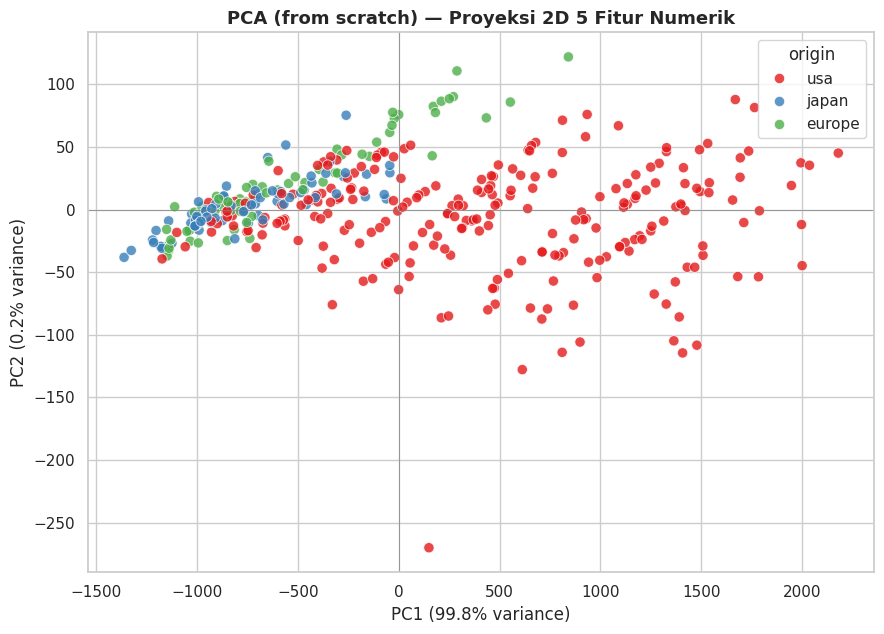

Explained variance ratio PC1: 0.9975 (99.75%)
Explained variance ratio PC2: 0.0021 (0.21%)
Total variance dijelaskan PC1+PC2: 99.96%


In [22]:
# 6. Plot 2D scatter + explained variance ratio
explained_variance_ratio = eigvals_sorted[:2] / eigvals_sorted.sum()

fig, ax = plt.subplots(figsize=(9, 6.5))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='origin', palette='Set1', s=55, alpha=0.8, ax=ax)
ax.set_title('PCA (from scratch) — Proyeksi 2D 5 Fitur Numerik', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({explained_variance_ratio[1]*100:.1f}% variance)')
ax.axhline(0, color='grey', linewidth=0.5)
ax.axvline(0, color='grey', linewidth=0.5)
plt.tight_layout()
plt.show()

print(f"Explained variance ratio PC1: {explained_variance_ratio[0]:.4f} ({explained_variance_ratio[0]*100:.2f}%)")
print(f"Explained variance ratio PC2: {explained_variance_ratio[1]:.4f} ({explained_variance_ratio[1]*100:.2f}%)")
print(f"Total variance dijelaskan PC1+PC2: {explained_variance_ratio.sum()*100:.2f}%")

**Interpretasi:** PC1 saja umumnya sudah menjelaskan proporsi variance yang
sangat besar — ini konsisten dengan temuan multikolinearitas sebelumnya
(`displacement`, `horsepower`, `weight` sangat berkorelasi), sehingga sebagian
besar informasi dari kelima fitur bisa "dipadatkan" ke dalam satu-dua komponen
utama tanpa banyak kehilangan informasi.

---
## Bonus 3 — Reusable EDA Class: `DatasetProfiler`

In [23]:
class DatasetProfiler:
    """Kelas EDA yang dapat digunakan kembali untuk dataset numerik apa pun."""

    def __init__(self, df: pd.DataFrame, target_col: str):
        self.df = df.copy()
        self.target_col = target_col
        self.numeric_cols = self.df.select_dtypes(include=[np.number]).columns.tolist()

    def summary_stats(self) -> pd.DataFrame:
        """Return DataFrame descriptive statistics (mean, median, std, IQR, outlier count) via NumPy."""
        rows = []
        for col in self.numeric_cols:
            arr = self.df[col].dropna().to_numpy(dtype=float)
            q1, q3 = np.percentile(arr, [25, 75])
            iqr = q3 - q1
            lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
            n_out = int(np.sum((arr < lower) | (arr > upper)))
            rows.append({
                'column': col,
                'mean': np.mean(arr),
                'median': np.median(arr),
                'std': np.std(arr, ddof=1),
                'IQR': iqr,
                'outlier_count': n_out
            })
        return pd.DataFrame(rows).set_index('column').round(3)

    def correlation_report(self) -> pd.Series:
        """Return Series korelasi semua fitur numerik terhadap target, terurut."""
        corr = self.df[self.numeric_cols].corr()[self.target_col].drop(self.target_col)
        return corr.sort_values(ascending=False)

    def plot_dashboard(self):
        """Generate figure 4 subplots: distribusi target, boxplot kategori, heatmap korelasi, scatter fitur terkuat vs target."""
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        # (1) Distribusi target
        sns.histplot(self.df[self.target_col], kde=True, ax=axes[0, 0], color='#4C72B0')
        axes[0, 0].set_title(f'Distribusi {self.target_col}')

        # (2) Boxplot per kategori (jika ada kolom kategorikal)
        cat_cols = self.df.select_dtypes(include=['object', 'category']).columns.tolist()
        if cat_cols:
            cat_col = cat_cols[0]
            sns.boxplot(data=self.df, x=cat_col, y=self.target_col, ax=axes[0, 1], palette='Set2')
            axes[0, 1].set_title(f'{self.target_col} per {cat_col}')
        else:
            axes[0, 1].text(0.5, 0.5, 'Tidak ada kolom kategorikal', ha='center', va='center')
            axes[0, 1].set_axis_off()

        # (3) Correlation heatmap
        corr_matrix_ = self.df[self.numeric_cols].corr()
        sns.heatmap(corr_matrix_, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1, 0])
        axes[1, 0].set_title('Correlation Heatmap')

        # (4) Scatter fitur paling berkorelasi vs target
        corr_report = self.correlation_report()
        strongest_feature = corr_report.abs().idxmax()
        sns.scatterplot(data=self.df, x=strongest_feature, y=self.target_col, ax=axes[1, 1], alpha=0.6)
        axes[1, 1].set_title(f'{strongest_feature} vs {self.target_col} (r={corr_report[strongest_feature]:.2f})')

        plt.tight_layout()
        plt.show()

    def generate_report(self) -> dict:
        """Return dictionary JSON-serialisable berisi semua temuan kunci."""
        stats = self.summary_stats()
        corr_report = self.correlation_report()
        strongest_feature = corr_report.abs().idxmax()

        return {
            'target_col': self.target_col,
            'n_rows': int(len(self.df)),
            'n_numeric_features': len(self.numeric_cols),
            'summary_stats': stats.reset_index().to_dict(orient='records'),
            'correlation_to_target': corr_report.round(4).to_dict(),
            'strongest_predictor': strongest_feature,
            'strongest_predictor_corr': round(float(corr_report[strongest_feature]), 4),
            'target_mean': round(float(self.df[self.target_col].mean()), 3),
            'target_median': round(float(self.df[self.target_col].median()), 3),
        }

=== summary_stats() ===


,mean,median,std,IQR,outlier_count
column,,,,,
mpg,23.515,23.0,7.816,11.50,1
cylinders,5.455,4.0,1.701,4.00,0
displacement,193.426,148.5,104.270,157.75,0
horsepower,104.304,93.5,38.223,49.00,11
weight,2970.425,2803.5,846.842,1384.25,0
acceleration,15.568,15.5,2.758,3.35,7
model_year,76.010,76.0,3.698,6.00,0
decade,1972.236,1970.0,4.172,0.00,89



=== correlation_report() ===


model_year      0.579267
decade          0.577124
acceleration    0.420289
horsepower     -0.773453
cylinders      -0.775396
displacement   -0.804203
weight         -0.831741
Name: mpg, dtype: float64


=== plot_dashboard() ===


/tmp/ipykernel_559/2677313998.py:42: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = self.df.select_dtypes(include=['object', 'category']).columns.tolist()
/tmp/ipykernel_559/2677313998.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=self.df, x=cat_col, y=self.target_col, ax=axes[0, 1], palette='Set2')


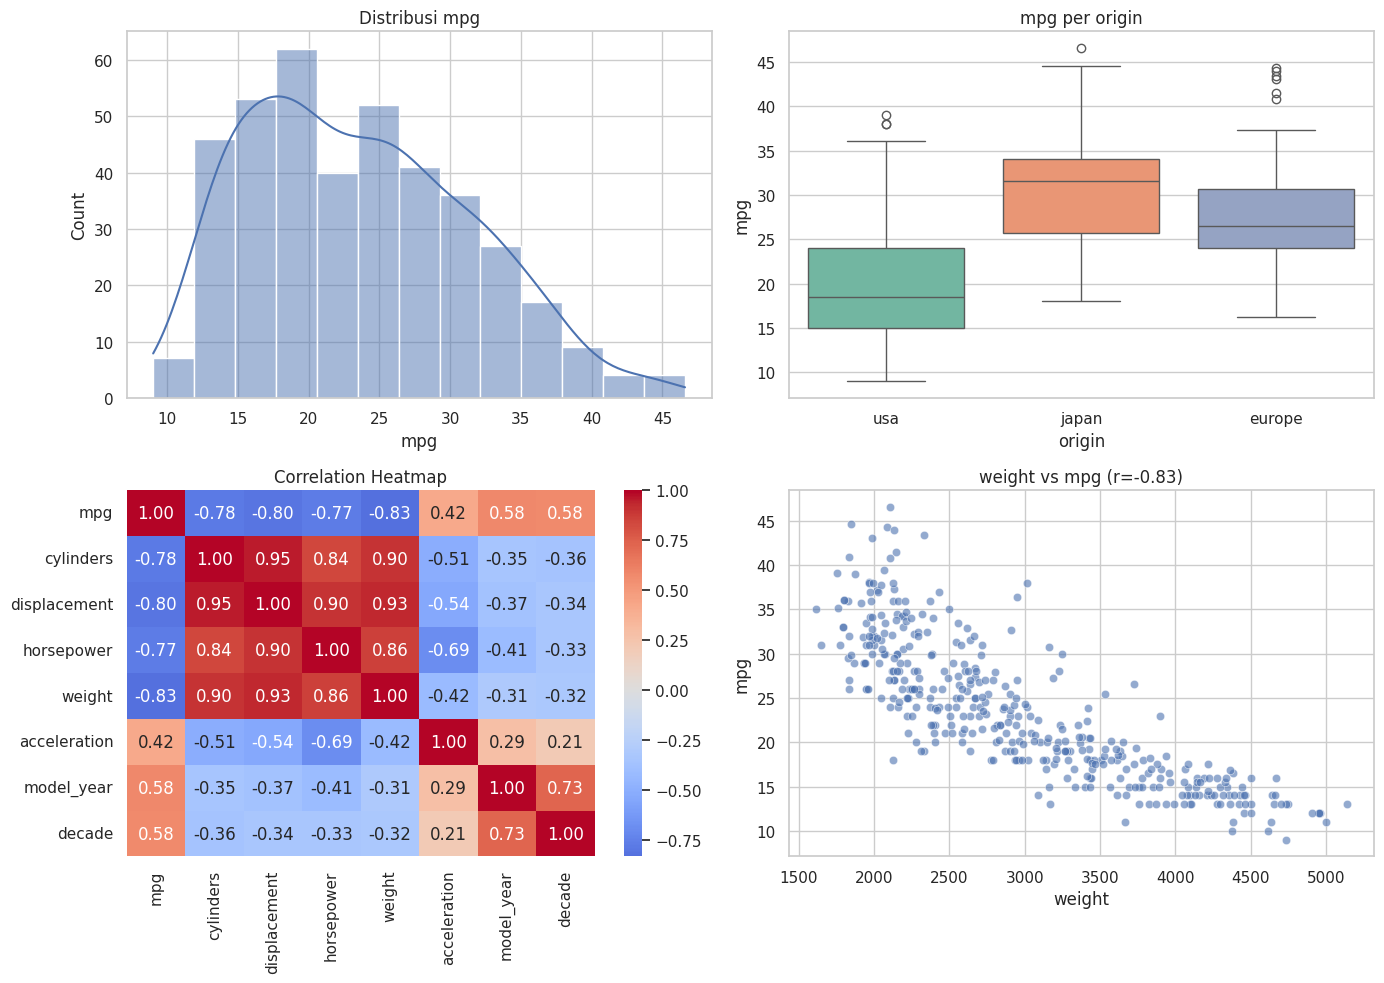


=== generate_report() ===
{
  "target_col": "mpg",
  "n_rows": 398,
  "n_numeric_features": 8,
  "summary_stats": [
    {
      "column": "mpg",
      "mean": 23.515,
      "median": 23.0,
      "std": 7.816,
      "IQR": 11.5,
      "outlier_count": 1
    },
    {
      "column": "cylinders",
      "mean": 5.455,
      "median": 4.0,
      "std": 1.701,
      "IQR": 4.0,
      "outlier_count": 0
    },
    {
      "column": "displacement",
      "mean": 193.426,
      "median": 148.5,
      "std": 104.27,
      "IQR": 157.75,
      "outlier_count": 0
    },
    {
      "column": "horsepower",
      "mean": 104.304,
      "median": 93.5,
      "std": 38.223,
      "IQR": 49.0,
      "outlier_count": 11
    },
    {
      "column": "weight",
      "mean": 2970.425,
      "median": 2803.5,
      "std": 846.842,
      "IQR": 1384.25,
      "outlier_count": 0
    },
    {
      "column": "acceleration",
      "mean": 15.568,
      "median": 15.5,
      "std": 2.758,
      "IQR": 3.35,
   

In [24]:
# Demonstrasi DatasetProfiler pada dataset MPG
profiler = DatasetProfiler(df, target_col='mpg')

print("=== summary_stats() ===")
display(profiler.summary_stats())

print("\n=== correlation_report() ===")
display(profiler.correlation_report())

print("\n=== plot_dashboard() ===")
profiler.plot_dashboard()

print("\n=== generate_report() ===")
report = profiler.generate_report()
import json
print(json.dumps(report, indent=2))

---
## Kesimpulan

Analisis menyeluruh terhadap dataset MPG menunjukkan bahwa **berat kendaraan
(`weight`)** adalah prediktor tunggal terkuat terhadap efisiensi bahan bakar,
dengan `displacement` dan `horsepower` memberikan sinyal serupa akibat
multikolinearitas yang tinggi di antara ketiganya. Efisiensi bahan bakar
meningkat dari dekade 1970-an ke 1980-an, sejalan dengan tren industri menuju
kendaraan yang lebih ringan dan efisien pasca krisis minyak. Mobil buatan
Jepang secara konsisten menunjukkan efisiensi tertinggi, sedangkan mobil
buatan USA cenderung paling boros namun paling beragam.